# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-3B  
**Architecture:** Multimodal Fusion + CBAM  
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini

This notebook evaluates whether adding Convolutional Block Attention Modules (CBAM)
to the multimodal RGB–LiDAR–IMU fusion network improves
BEV occupancy prediction.

This experiment keeps the training pipeline identical to
Phase 3 while introducing lightweight channel and spatial
attention after multimodal feature fusion.

### Experiment Configuration

| Item | Value |
|------|-------|
| Dataset | Moving Object BEV Dataset |
| Inputs | RGB + LiDAR BEV + IMU |
| Output | Binary BEV Occupancy |
| Backbone | Fusion Baseline |
| Attention | CBAM |
| Loss | Hybrid Loss |
| Optimizer | Adam |
| Epochs | 40 |
| Batch Size | 8 |
| Hardware | NVIDIA L4 GPU |

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
checkpoints	data	    dummy.onnx	nuscenes   reports  src
colab_packages	deployment  notebooks	README.md  scripts


In [ ]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [ ]:
import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

In [ ]:
# ---------------------------------------------------
# Runtime configuration
# ---------------------------------------------------
import torch
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
import os
import time
import random

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from tqdm import tqdm

from src.dataset_utils import RGBBEVDataset
from src.losses import HybridLoss
from src.model.fusion_cbam import FusionCBAMModel
from src.report_utils import save_report

In [ ]:
# ---------------------------------------------------
# Dataset configuration
# ---------------------------------------------------
data_dir = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "project3_multimodal_bev_perception/"
    "data/preprocessed_moving"
)


# ---------------------------------------------------
# Discover all preprocessed HDF5 files
# ---------------------------------------------------
files = sorted(
    [
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.endswith(".h5")
    ]
)

print(f"Found {len(files)} HDF5 files.")


# ---------------------------------------------------
# Train / validation split (80% / 20%)
# ---------------------------------------------------
split_idx = int(0.8 * len(files))

train_files = files[:split_idx]
val_files = files[split_idx:]


# ---------------------------------------------------
# Create datasets
# ---------------------------------------------------
train_set = RGBBEVDataset(train_files)

val_set = RGBBEVDataset(val_files)


# ---------------------------------------------------
# Create data loaders
# ---------------------------------------------------
train_loader = DataLoader(
    train_set,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_set,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)


# ---------------------------------------------------
# Verify one sample
# ---------------------------------------------------
rgb, bev, imu = train_set[0]

print("\nSample Shapes")
print(f"RGB : {tuple(rgb.shape)}")
print(f"BEV : {tuple(bev.shape)}")
print(f"IMU : {tuple(imu.shape)}")


# ---------------------------------------------------
# Dataset summary
# ---------------------------------------------------
print("\nDataset Summary")
print(f"Training samples   : {len(train_set)}")
print(f"Validation samples : {len(val_set)}")

Found 323 HDF5 files.

Sample Shapes
RGB : (3, 256, 256)
BEV : (1, 200, 200)
IMU : (10, 6)

Dataset Summary
Training samples   : 258
Validation samples : 65


## 3. Fusion + CBAM Architecture

The baseline multimodal fusion network is augmented
with a Convolutional Block Attention Module (CBAM).

The attention module applies

- Channel Attention
- Spatial Attention

before feature decoding to investigate whether
feature refinement improves BEV occupancy prediction.

In [ ]:
import torch
import torch.optim as optim

from src.model.fusion_cbam import FusionCBAMModel


# ---------------------------------------------------
# Initialize Fusion + CBAM model
# ---------------------------------------------------
model = FusionCBAMModel().to(device)

# print(model)


# ---------------------------------------------------
# Optimizer & Loss
# ---------------------------------------------------
loss_fn = HybridLoss(
    bce_weight=0.7,
)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)


# ---------------------------------------------------
# Model Summary
# ---------------------------------------------------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Fusion + CBAM Attention")
print("-" * 25)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Fusion + CBAM Attention
-------------------------
Total parameters     : 374,227
Trainable parameters : 374,227


In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-80GB


In [ ]:
import os
import time

from tqdm import tqdm


def soft_iou(
    pred,
    target,
    smooth=1e-6,
):
    """
    Compute the mean binary Intersection-over-Union (IoU)
    between predicted probability maps and ground-truth
    BEV occupancy maps.
    """

    pred_bin = (pred > 0.5).float()

    intersection = (
        pred_bin * target
    ).sum(dim=(2, 3))

    union = (
        pred_bin.sum(dim=(2, 3))
        + target.sum(dim=(2, 3))
        - intersection
    )

    return (
        (intersection + smooth)
        / (union + smooth)
    ).mean().item()


# ---------------------------------------------------
# Training configuration
# ---------------------------------------------------
EPOCHS = 40

best_val_iou = 0.0

t0 = time.time()


# ---------------------------------------------------
# Training loop
# ---------------------------------------------------
for epoch in range(EPOCHS):

    model.train()

    train_loss = 0.0

    for rgb, bev, imu in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        ncols=90,
    ):

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        if bev.shape[-2:] != logits.shape[-2:]:

            bev = F.interpolate(
                bev,
                size=logits.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        loss = loss_fn(
            logits,
            bev,
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------------------------------------
    # Validation
    # ---------------------------------------------------
    model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for rgb, bev, imu in val_loader:

            rgb = rgb.to(device)
            bev = bev.to(device)
            imu = imu.to(device)

            logits = model(
                rgb,
                bev,
                imu,
            )

            probabilities = torch.sigmoid(
                logits
            )

            if bev.shape[-2:] != probabilities.shape[-2:]:

                bev = F.interpolate(
                    bev,
                    size=probabilities.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )

            val_loss += loss_fn(
                logits,
                bev,
            ).item()

            val_iou += soft_iou(
                probabilities,
                bev,
            )

    val_loss /= len(val_loader)

    val_iou /= len(val_loader)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

    # ---------------------------------------------------
    # Save the checkpoint with the highest validation IoU.
    # ---------------------------------------------------
    if val_iou > best_val_iou:

        best_val_iou = val_iou

        os.makedirs(
            "checkpoints",
            exist_ok=True,
        )

        torch.save(
            model.state_dict(),
            "checkpoints/fusion_cbam_best.pth",
        )


# ---------------------------------------------------
# Training summary
# ---------------------------------------------------
t1 = time.time()

print("\nTraining complete.")

print(
    f"Best Validation IoU : {best_val_iou:.4f}"
)

print(
    f"Training time       : {(t1 - t0) / 60:.2f} minutes"
)

Epoch 1/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 14.34it/s]


Epoch 01/40 | Train Loss: 0.8492 | Val Loss: 0.7795 | Val IoU: 0.3590


Epoch 2/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 13.83it/s]


Epoch 02/40 | Train Loss: 0.7810 | Val Loss: 0.7578 | Val IoU: 0.3875


Epoch 3/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 14.77it/s]


...

Epoch 38/40 | Train Loss: 0.4863 | Val Loss: 0.4740 | Val IoU: 0.5230


Epoch 39/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 14.34it/s]


Epoch 39/40 | Train Loss: 0.4801 | Val Loss: 0.4688 | Val IoU: 0.5179


Epoch 40/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 13.85it/s]


Epoch 40/40 | Train Loss: 0.4747 | Val Loss: 0.4629 | Val IoU: 0.5247

Training complete.
Best Validation IoU : 0.5247
Training time       : 1.83 minutes


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

from src.report_utils import save_report


def compute_metrics(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute binary IoU, Precision, Recall, and F1 score
    for a predicted BEV occupancy map.
    """

    pred_bin = (pred > thresh).astype(np.uint8)

    target_bin = (target > 0.5).astype(np.uint8)

    tp = np.logical_and(
        pred_bin == 1,
        target_bin == 1,
    ).sum()

    fp = np.logical_and(
        pred_bin == 1,
        target_bin == 0,
    ).sum()

    fn = np.logical_and(
        pred_bin == 0,
        target_bin == 1,
    ).sum()

    precision = tp / (tp + fp + 1e-6)

    recall = tp / (tp + fn + 1e-6)

    f1 = (
        2
        * precision
        * recall
        / (precision + recall + 1e-6)
    )

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    iou = intersection / (union + 1e-6)

    return (
        iou,
        precision,
        recall,
        f1,
    )


# ---------------------------------------------------
# Load best-performing checkpoint
# ---------------------------------------------------
checkpoint_path = "checkpoints/fusion_cbam_best.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Evaluate on the validation set
# ---------------------------------------------------
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for rgb, bev, imu in val_loader:

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        probabilities = torch.sigmoid(
            logits
        )

        if probabilities.shape[-2:] != bev.shape[-2:]:

            probabilities = F.interpolate(
                probabilities,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        pred_np = probabilities.cpu().numpy()

        bev_np = bev.cpu().numpy()

        for pred, target in zip(
            pred_np,
            bev_np,
        ):

            iou, precision, recall, f1 = compute_metrics(
                pred[0],
                target[0],
            )

            iou_scores.append(iou)

            precision_scores.append(precision)

            recall_scores.append(recall)

            f1_scores.append(f1)


# ---------------------------------------------------
# Quantitative summary
# ---------------------------------------------------
summary_dict = {
    "Mean IoU": np.mean(iou_scores),
    "Mean Precision": np.mean(precision_scores),
    "Mean Recall": np.mean(recall_scores),
    "Mean F1 Score": np.mean(f1_scores),
}

print(
    "Validation Metrics Summary — Fusion + CBAM\n"
)

for metric, value in summary_dict.items():

    print(
        f"{metric:17}: {value:.4f}"
    )


# ---------------------------------------------------
# Save evaluation report and update leaderboard
# ---------------------------------------------------
save_report(
    summary_dict=summary_dict,
    model_name="Fusion + CBAM",
    best_iou=np.mean(iou_scores),
    start_time=t0,
    end_time=t1,
    auto_update=True,
)

Validation Metrics Summary — Fusion + CBAM

Mean IoU         : 0.5592
Mean Precision   : 0.6116
Mean Recall      : 0.8667
Mean F1 Score    : 0.7170
 Markdown report saved → reports/fusion___cbam_summary.md
 CSV report saved → reports/fusion___cbam_summary.csv
 Leaderboard saved → reports/leaderboard.csv
️ Markdown summary → reports/leaderboard.md
 Leaderboard plot saved → reports/leaderboard.png


('reports/fusion___cbam_summary.md', 'reports/fusion___cbam_summary.csv')

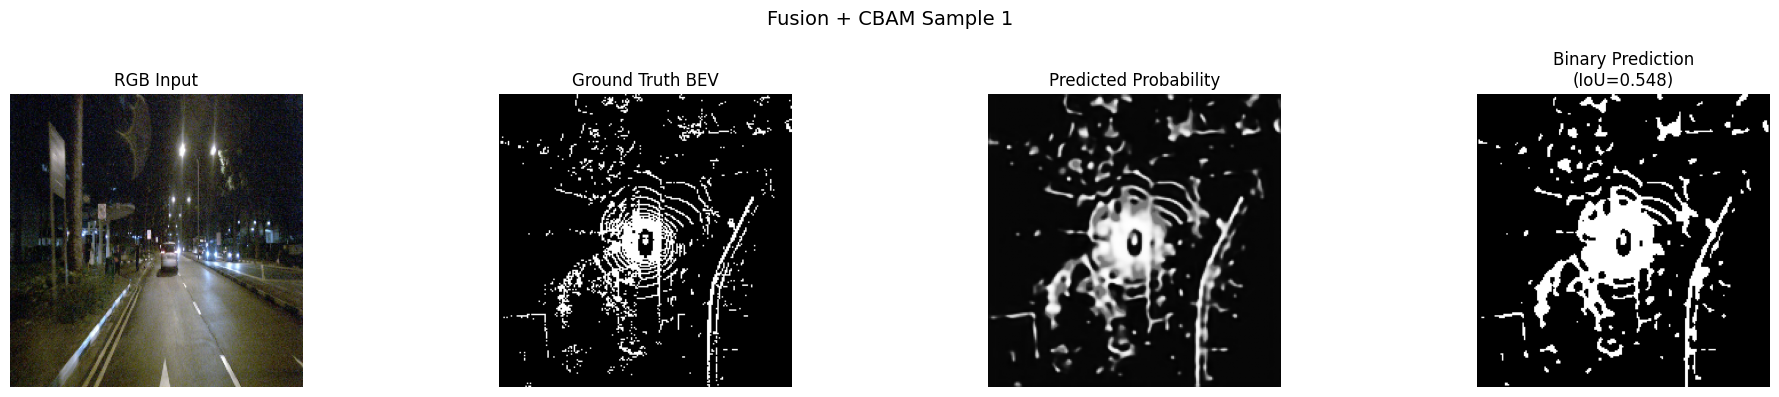

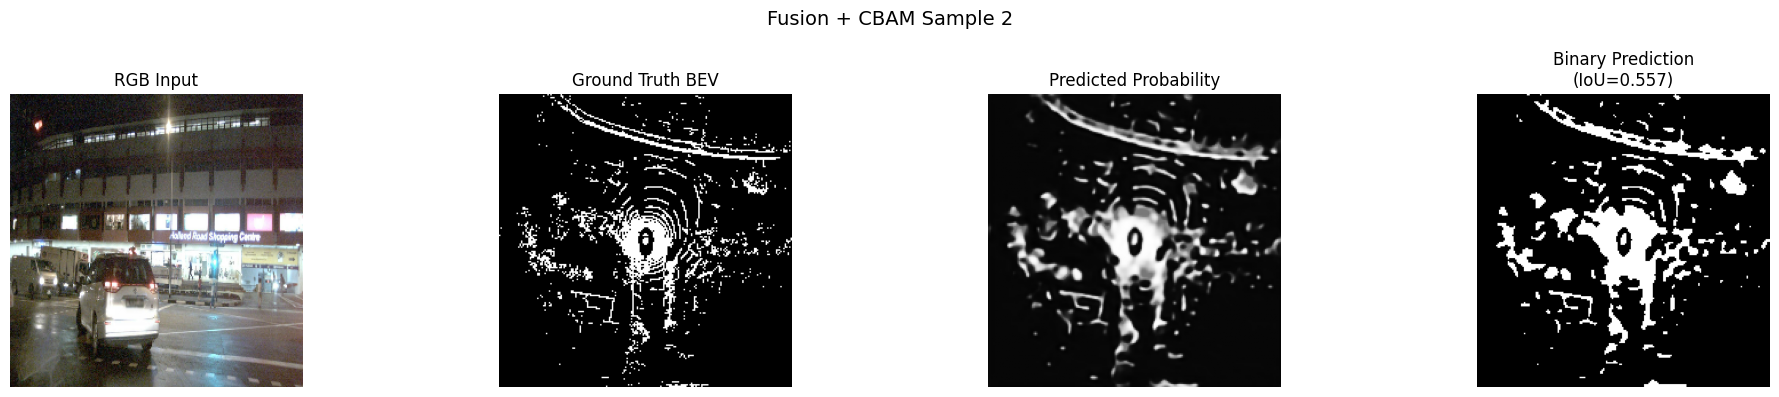

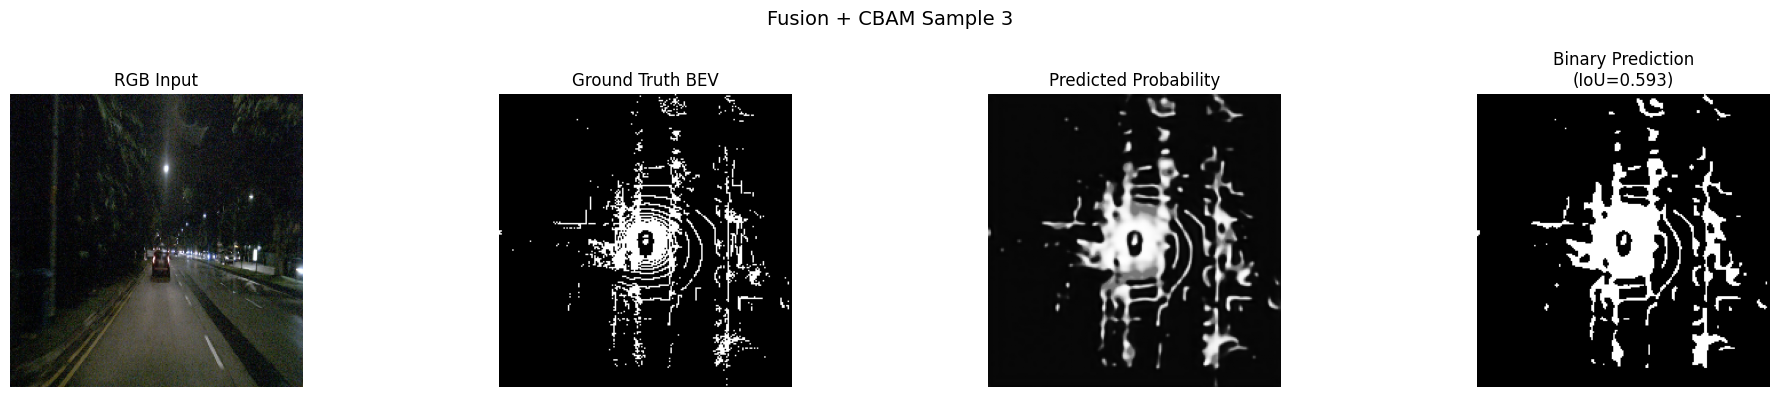

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------------------------------------------------
# Load the best-performing checkpoint
# ---------------------------------------------------
checkpoint_path = "checkpoints/fusion_cbam_best.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Randomly visualize validation samples
# ---------------------------------------------------
num_samples = 3

indices = random.sample(
    range(len(val_set)),
    num_samples,
)


for sample_num, idx in enumerate(indices, start=1):

    rgb, bev, imu = val_set[idx]

    rgb_in = rgb.unsqueeze(0).to(device)
    bev_in = bev.unsqueeze(0).to(device)
    imu_in = imu.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(
            rgb_in,
            bev_in,
            imu_in,
        )

        probabilities = torch.sigmoid(
            logits
        )

        if probabilities.shape[-2:] != bev_in.shape[-2:]:

            probabilities = F.interpolate(
                probabilities,
                size=bev_in.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

    pred_np = probabilities.squeeze().cpu().numpy()

    bev_np = bev.squeeze().cpu().numpy()

    rgb_np = np.transpose(
        rgb.cpu().numpy(),
        (1, 2, 0),
    )

    rgb_np = (
        (rgb_np + 1.0) / 2.0
    ).clip(0, 1)

    pred_bin = (
        pred_np > 0.5
    ).astype(np.float32)

    intersection = (
        pred_bin * bev_np
    ).sum()

    union = (
        pred_bin.sum()
        + bev_np.sum()
        - intersection
    )

    iou = intersection / (union + 1e-6)

    # ---------------------------------------------------
    # Visualization
    # ---------------------------------------------------
    fig, axs = plt.subplots(
        1,
        4,
        figsize=(20, 4),
    )

    axs[0].imshow(rgb_np)
    axs[0].set_title("RGB Input")
    axs[0].axis("off")

    axs[1].imshow(
        bev_np,
        cmap="gray",
    )
    axs[1].set_title("Ground Truth BEV")
    axs[1].axis("off")

    axs[2].imshow(
        pred_np,
        cmap="gray",
    )
    axs[2].set_title("Predicted Probability")
    axs[2].axis("off")

    axs[3].imshow(
        pred_bin,
        cmap="gray",
    )
    axs[3].set_title(
        f"Binary Prediction\n(IoU={iou:.3f})"
    )
    axs[3].axis("off")

    plt.suptitle(
        f"Fusion + CBAM Sample {sample_num}",
        fontsize=14,
    )

    plt.tight_layout()

    plt.show()

## 7. Summary

### Objective

Evaluate whether lightweight CBAM attention improves
multimodal RGB–LiDAR–IMU fusion for BEV occupancy prediction.

---

### Key Findings

- Training remained stable.
- CBAM successfully integrated into the fusion network.
- Validation IoU reached 0.559.
- The baseline Fusion model remained superior.

---

### Interpretation

The attention module increased model complexity but
did not improve segmentation quality on this dataset.

Qualitative results indicate increased false-positive
activations despite similar recall.

---

### Conclusion

This experiment demonstrates that architectural
modifications should be validated experimentally,
rather than assuming additional attention mechanisms
will always improve performance.

---

### Future Work

- Cross-modal attention
- Multi-scale attention
- Transformer fusion
- Learnable modality weighting